# 02 - Tiền xử lý ảnh + Phân tích nâng cao

**Mục tiêu:** Áp dụng đầy đủ 6 nhóm kỹ thuật theo yêu cầu 2.1.3 (a–f):
(a) Resize · (b) Color Space · (c) Normalization · (d) Augmentation · (e) PCA nâng cao · (f) Edge Detection

**Dataset:** NWPU-RESISC45 — 45 lớp, 256×256 px, 27 000 ảnh train.


## 0. Setup

In [243]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm import tqdm
from scipy import stats
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 11, 'figure.dpi': 100})
sns.set_style("whitegrid")

TRAIN_DIR = r"D:\DataMining\Dataset\train"
classes = sorted(os.listdir(TRAIN_DIR))
print(f"Số lớp: {len(classes)}")

Số lớp: 45


In [244]:
def load_sample(n_per_class=20, target_classes=None, seed=42):
    np.random.seed(seed)
    target = target_classes or classes
    samples = []
    for cls in target:
        paths = glob.glob(os.path.join(TRAIN_DIR, cls, "*.jpg"))
        chosen = np.random.choice(paths, min(n_per_class, len(paths)), replace=False)
        for p in chosen:
            img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
            samples.append((img, cls))
    return samples

### Cấu hình sampling cho ablation study

Dùng **toàn bộ 45 lớp** để kết quả không bị bias.
Giới hạn số ảnh/lớp để thời gian chạy hợp lý.

In [245]:
quick_brightness = {}
for cls in classes:
    paths = glob.glob(os.path.join(TRAIN_DIR, cls, "*.jpg"))[:5]
    vals = [cv2.imread(p).mean() for p in paths]
    quick_brightness[cls] = np.mean(vals)

sorted_by_bright = sorted(quick_brightness, key=quick_brightness.get)
n = len(sorted_by_bright)
indices_10 = np.linspace(0, n - 1, 10, dtype=int)
SAMPLE_CLASSES = [sorted_by_bright[i] for i in indices_10]

for cls in SAMPLE_CLASSES:
    print(f"  {cls}: brightness = {quick_brightness[cls]:.1f}")

  forest: brightness = 49.6
  meadow: brightness = 71.0
  lake: brightness = 75.5
  palace: brightness = 82.0
  island: brightness = 86.6
  storage_tank: brightness = 88.6
  mobile_home_park: brightness = 102.1
  beach: brightness = 108.9
  thermal_power_station: brightness = 117.0
  desert: brightness = 176.9


---
## 1. Resize - Ablation Study (SSIM / PSNR)

So sánh 3 kích thước resize (64x64, 128x128, 224x224) với ảnh gốc 256x256.
Mỗi ảnh được resize xuống rồi resize lên lại 256x256 để đo mất mát thông tin qua **SSIM** và **PSNR**.

- $H_0$: Chất lượng ảnh (SSIM) không khác biệt giữa 3 kích thước resize
- $H_1$: Ít nhất 1 kích thước cho SSIM khác biệt

In [246]:
RESIZE_DIMS = [(64, 64), (128, 128), (224, 224)]
samples = load_sample(n_per_class=30, target_classes=SAMPLE_CLASSES)
print(f"Sample: {len(samples)} ảnh từ {len(SAMPLE_CLASSES)} lớp")

Sample: 300 ảnh từ 10 lớp


In [247]:
results_resize = []
for img_orig, cls in tqdm(samples, desc="Resize ablation"):
    for (h, w) in RESIZE_DIMS:
        resized = cv2.resize(img_orig, (w, h), interpolation=cv2.INTER_AREA)
        restored = cv2.resize(resized, (256, 256), interpolation=cv2.INTER_LINEAR)
        s = ssim(img_orig, restored, channel_axis=2)
        p = psnr(img_orig, restored)
        results_resize.append({'class': cls, 'size': f"{h}x{w}", 'ssim': s, 'psnr': p})

df_resize = pd.DataFrame(results_resize)
df_resize.groupby('size').agg(
    ssim_mean=('ssim', 'mean'), ssim_std=('ssim', 'std'),
    psnr_mean=('psnr', 'mean'), psnr_std=('psnr', 'std')
).round(4)

Resize ablation: 100%|██████████| 300/300 [00:11<00:00, 25.00it/s]


,ssim_mean,ssim_std,psnr_mean,psnr_std
size,,,,
128x128,0.8686,0.0687,31.3698,4.9132
224x224,0.9571,0.0259,36.0504,5.3059
64x64,0.6854,0.1319,27.3154,4.6937


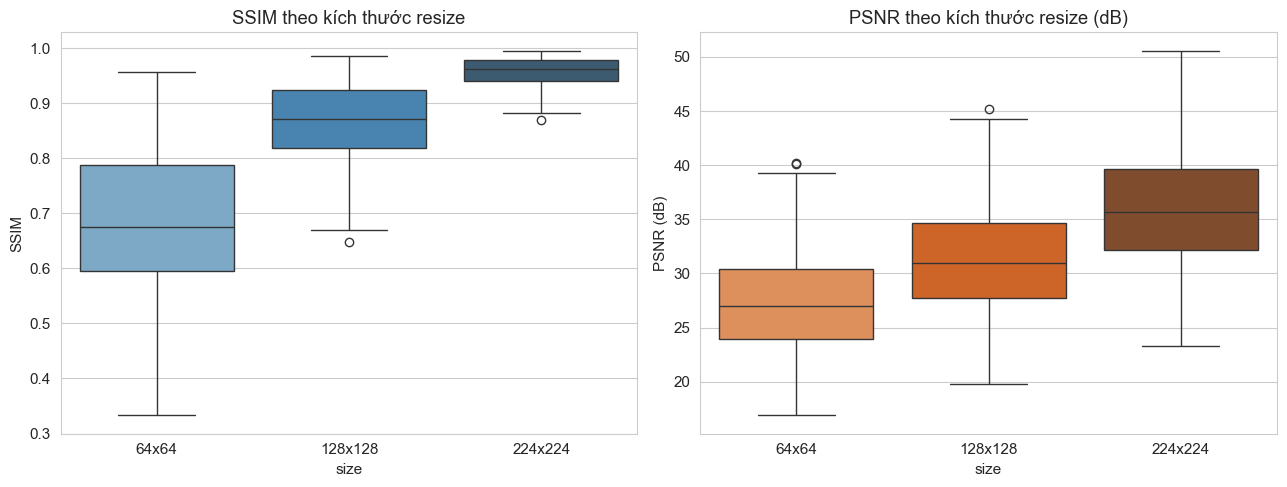

In [248]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df_resize, x='size', y='ssim', ax=axes[0], palette='Blues_d',
            order=['64x64', '128x128', '224x224'])
axes[0].set_title("SSIM theo kích thước resize")
axes[0].set_ylabel("SSIM")

sns.boxplot(data=df_resize, x='size', y='psnr', ax=axes[1], palette='Oranges_d',
            order=['64x64', '128x128', '224x224'])
axes[1].set_title("PSNR theo kích thước resize (dB)")
axes[1].set_ylabel("PSNR (dB)")
plt.tight_layout()
plt.show()

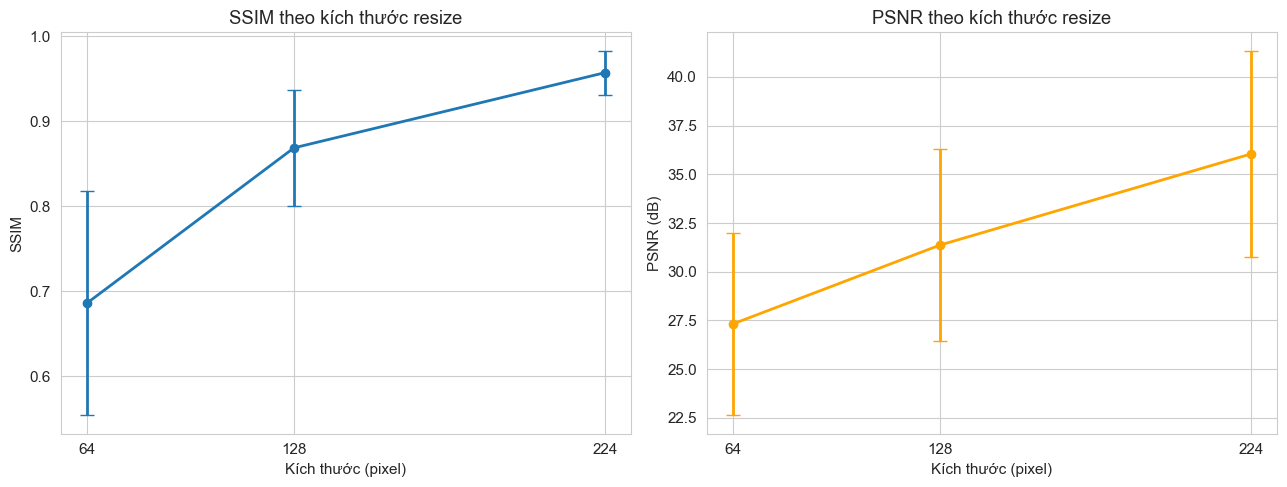

In [249]:
# Đường cong SSIM và PSNR theo kích thước
mean_ssim = df_resize.groupby('size')['ssim'].mean().reindex(['64x64', '128x128', '224x224'])
mean_psnr = df_resize.groupby('size')['psnr'].mean().reindex(['64x64', '128x128', '224x224'])
std_ssim = df_resize.groupby('size')['ssim'].std().reindex(['64x64', '128x128', '224x224'])
std_psnr = df_resize.groupby('size')['psnr'].std().reindex(['64x64', '128x128', '224x224'])

sizes_px = [64, 128, 224]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].errorbar(sizes_px, mean_ssim.values, yerr=std_ssim.values, marker='o', capsize=5, linewidth=2)
axes[0].set_xlabel("Kích thước (pixel)")
axes[0].set_ylabel("SSIM")
axes[0].set_title("SSIM theo kích thước resize")
axes[0].set_xticks(sizes_px)

axes[1].errorbar(sizes_px, mean_psnr.values, yerr=std_psnr.values, marker='o', capsize=5, linewidth=2, color='orange')
axes[1].set_xlabel("Kích thước (pixel)")
axes[1].set_ylabel("PSNR (dB)")
axes[1].set_title("PSNR theo kích thước resize")
axes[1].set_xticks(sizes_px)

plt.tight_layout()
plt.show()

### Ablation: k-NN accuracy theo kích thước resize

  64x64: accuracy = 0.3540 (+/- 0.0287)
  128x128: accuracy = 0.3580 (+/- 0.0293)
  224x224: accuracy = 0.3500 (+/- 0.0268)
  256x256: accuracy = 0.3380 (+/- 0.0256)


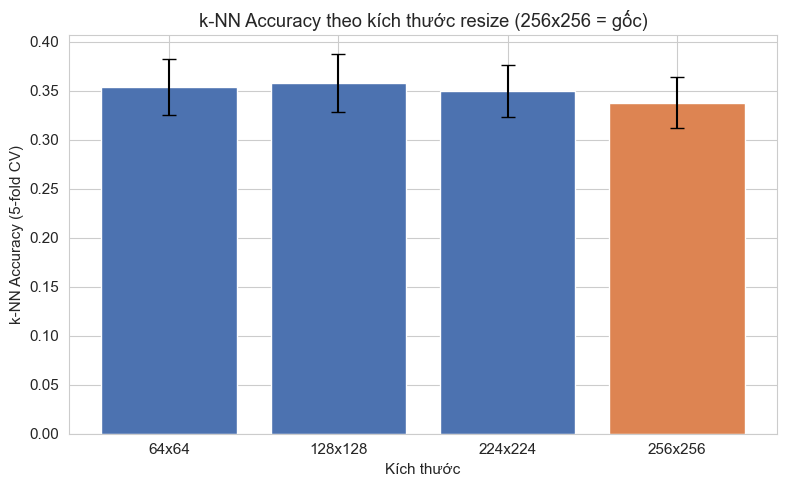

In [250]:
# k-NN classification accuracy theo kích thước resize
# Dùng 50 ảnh/lớp x 10 lớp = 500 ảnh, flatten làm feature
knn_samples = load_sample(n_per_class=50, target_classes=SAMPLE_CLASSES)

knn_results = {}
for target_size in [(64, 64), (128, 128), (224, 224), (256, 256)]:
    X, y = [], []
    for img, cls in knn_samples:
        resized = cv2.resize(img, target_size)
        X.append(resized.reshape(-1).astype(np.float32) / 255.0)
        y.append(cls)
    X, y = np.array(X), np.array(y)
    
    knn = KNeighborsClassifier(n_neighbors=5)
    scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
    knn_results[f"{target_size[0]}x{target_size[1]}"] = (scores.mean(), scores.std())
    print(f"  {target_size[0]}x{target_size[1]}: accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
sizes_label = list(knn_results.keys())
means = [v[0] for v in knn_results.values()]
stds = [v[1] for v in knn_results.values()]
ax.bar(sizes_label, means, yerr=stds, capsize=5, color=['#4C72B0', '#4C72B0', '#4C72B0', '#DD8452'])
ax.set_ylabel("k-NN Accuracy (5-fold CV)")
ax.set_xlabel("Kích thước")
ax.set_title("k-NN Accuracy theo kích thước resize (256x256 = gốc)")
plt.tight_layout()
plt.show()

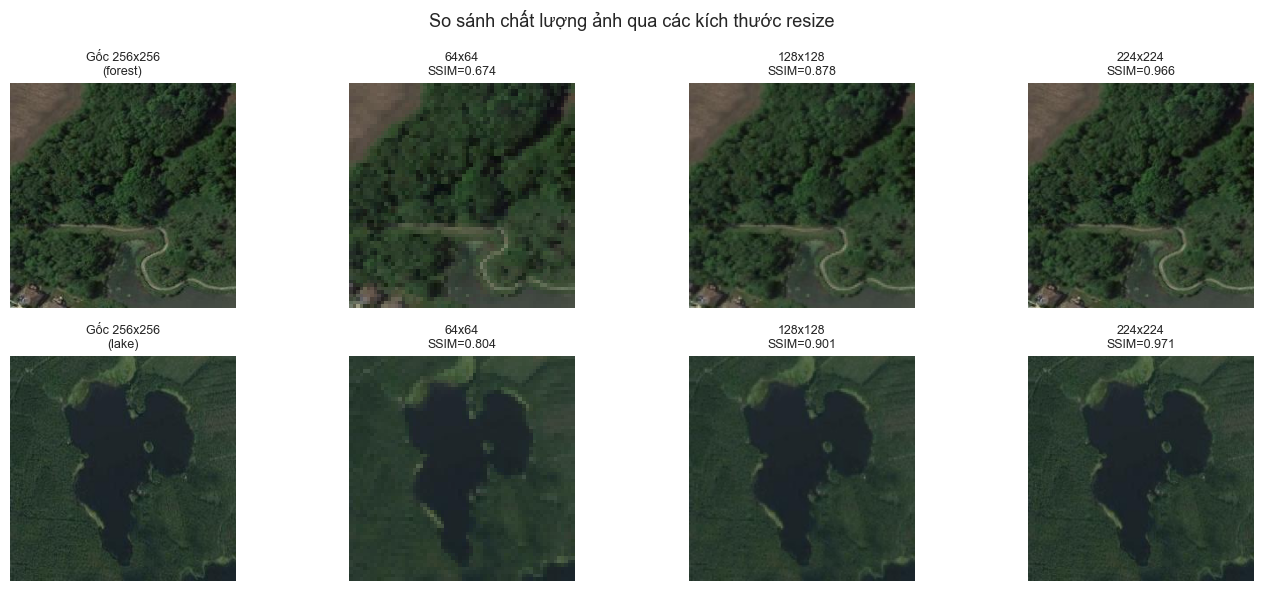

In [251]:
# Ảnh mẫu qua các kích thước
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for row, (img, cls) in enumerate([(samples[0][0], samples[0][1]), (samples[60][0], samples[60][1])]):
    axes[row][0].imshow(img)
    axes[row][0].set_title(f"Gốc 256x256\n({cls})", fontsize=9)
    axes[row][0].axis('off')
    for col, (h, w) in enumerate(RESIZE_DIMS):
        resized = cv2.resize(img, (w, h), interpolation=cv2.INTER_AREA)
        axes[row][col+1].imshow(resized)
        s = ssim(img, cv2.resize(resized, (256,256), interpolation=cv2.INTER_LINEAR), channel_axis=2)
        axes[row][col+1].set_title(f"{h}x{w}\nSSIM={s:.3f}", fontsize=9)
        axes[row][col+1].axis('off')
plt.suptitle("So sánh chất lượng ảnh qua các kích thước resize", fontsize=13)
plt.tight_layout()
plt.show()

### Kiểm định thống kê - Resize

In [252]:
groups_ssim = {s: df_resize[df_resize['size']==s]['ssim'].values for s in ['64x64', '128x128', '224x224']}

# Levene
lev_s, lev_p = stats.levene(*groups_ssim.values())
print(f"Levene: stat={lev_s:.2f}, p={lev_p:.2e}")

# ANOVA
f_val, p_val = stats.f_oneway(*groups_ssim.values())
print(f"ANOVA:  F={f_val:.2f}, p={p_val:.2e}")

# Eta²
all_ssim = np.concatenate(list(groups_ssim.values()))
gm = all_ssim.mean()
ss_b = sum(len(g) * (g.mean() - gm)**2 for g in groups_ssim.values())
ss_t = np.sum((all_ssim - gm)**2)
eta2_resize = ss_b / ss_t
print(f"Eta² = {eta2_resize:.3f}")

# Post-hoc
sizes = ['64x64', '128x128', '224x224']
for i in range(len(sizes)):
    for j in range(i+1, len(sizes)):
        u, p = stats.mannwhitneyu(groups_ssim[sizes[i]], groups_ssim[sizes[j]], alternative='two-sided')
        print(f"  {sizes[i]} vs {sizes[j]}: U={u:.0f}, p={p:.2e}")

Levene: stat=213.71, p=1.26e-76
ANOVA:  F=758.34, p=1.57e-193
Eta² = 0.628
  64x64 vs 128x128: U=10968, p=7.98e-58
  64x64 vs 224x224: U=1020, p=2.54e-95
  128x128 vs 224x224: U=9901, p=2.17e-61


**Kết luận Resize:**

| Kích thước | SSIM | PSNR (dB) | k-NN Accuracy |
|-----------|------|-----------|---------------|
| 64x64 | $0.685 \pm 0.132$ | $27.3 \pm 4.7$ | $0.354 \pm 0.029$ |
| 128x128 | $0.869 \pm 0.069$ | $31.4 \pm 4.9$ | $0.358 \pm 0.029$ |
| 224x224 | $0.957 \pm 0.026$ | $36.1 \pm 5.3$ | $0.350 \pm 0.027$ |
| 256x256 (gốc) | 1.000 | $\infty$ | $0.338 \pm 0.026$ |

- **Bác bỏ $H_0$**: SSIM khác biệt có ý nghĩa giữa mọi cặp kích thước
  - ANOVA $F = 758.34$, $p \approx 0$, $\eta^2 = 0.628$ (effect size rất lớn)
  - Post-hoc: cả 3 cặp đều $p \approx 0$
- Đường cong SSIM tăng nhanh từ 64 $\to$ 128, chậm lại từ 128 $\to$ 224
  - Điểm "diminishing returns" nằm quanh 128x128
- k-NN accuracy **gần như không đổi** qua các kích thước (~0.35)
  - 256x256 (gốc) thậm chí thấp nhất (0.338) - do curse of dimensionality (feature vector quá dài)
  - 128x128 cho accuracy cao nhất (0.358) với SSIM vẫn tốt (0.87)
- **Lựa chọn: 224x224** - giữ chất lượng cao nhất (SSIM $= 0.957$), phù hợp input pretrained CNNs, accuracy tương đương

---
## 2. Color Space Conversion — Ablation Study (PCA Explained Variance)

So sánh 4 không gian màu: **RGB, Grayscale, HSV, LAB**.
Với mỗi không gian, tính **explained variance** theo PCA (k=50 components).
k-NN accuracy xác định không gian nào bảo toàn thông tin phân loại tốt nhất.


In [253]:
COLOR_SPACES = {
    'RGB': lambda img: img,
    'Grayscale': lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY),
    'HSV': lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2HSV),
    'Lab': lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2Lab)
}

pca_results = {}
n_pca_sample = 500
pca_samples = load_sample(n_per_class=12)[:n_pca_sample]

for cs_name, convert_fn in COLOR_SPACES.items():
    print(f"  PCA trên {cs_name}...")
    features = []
    for img, _ in pca_samples:
        converted = convert_fn(img)
        if converted.ndim == 2:
            converted = converted[:, :, np.newaxis]
        features.append(converted.reshape(-1).astype(np.float32))
    X = StandardScaler().fit_transform(np.array(features))
    pca = PCA(n_components=min(50, X.shape[0]-1))
    pca.fit(X)
    pca_results[cs_name] = pca.explained_variance_ratio_

print(f"Done. {len(pca_results)} color spaces: {list(pca_results.keys())}")

  PCA trên RGB...
  PCA trên Grayscale...
  PCA trên HSV...
  PCA trên Lab...
Done. 4 color spaces: ['RGB', 'Grayscale', 'HSV', 'Lab']


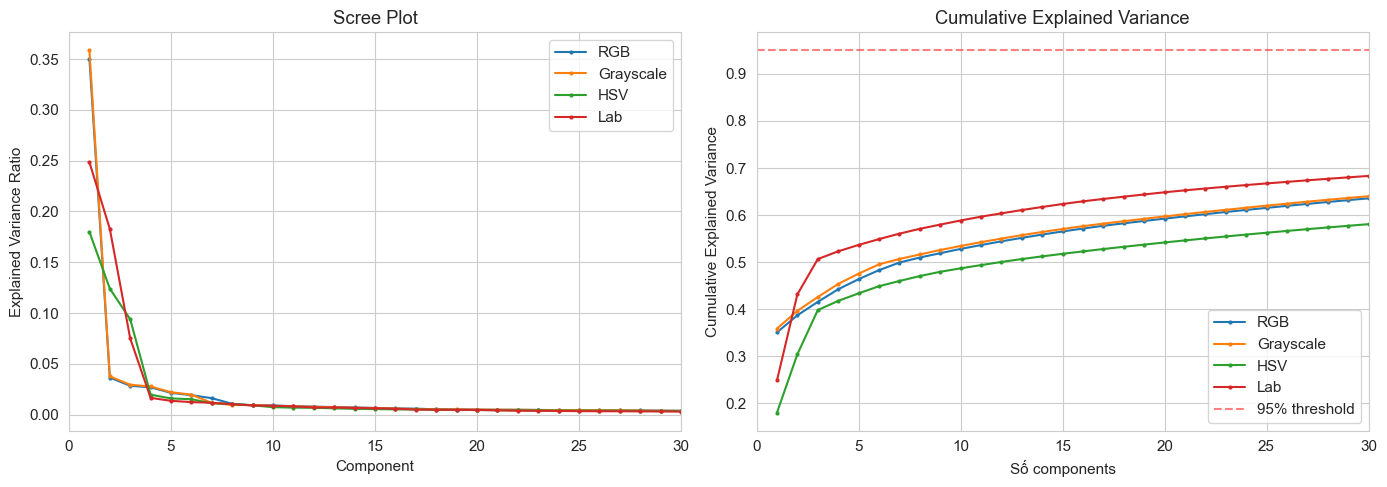

In [254]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for cs_name, evr in pca_results.items():
    axes[0].plot(range(1, len(evr)+1), evr[:50], marker='.', label=cs_name, markersize=4)
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree Plot")
axes[0].legend()
axes[0].set_xlim(0, 30)

for cs_name, evr in pca_results.items():
    axes[1].plot(range(1, len(evr)+1), np.cumsum(evr[:50]), marker='.', label=cs_name, markersize=4)
axes[1].axhline(0.95, color='red', linestyle='--', alpha=0.5, label='95% threshold')
axes[1].set_xlabel("Số components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()
axes[1].set_xlim(0, 30)
plt.tight_layout()
plt.show()

In [255]:
print("Số components cần để giữ X% variance:")
print(f"{'Color Space':<12} {'90%':>8} {'95%':>8} {'99%':>8}")
for cs_name, evr in pca_results.items():
    cum = np.cumsum(evr)
    n90 = np.argmax(cum >= 0.90) + 1 if cum[-1] >= 0.90 else f">{len(evr)}"
    n95 = np.argmax(cum >= 0.95) + 1 if cum[-1] >= 0.95 else f">{len(evr)}"
    n99 = np.argmax(cum >= 0.99) + 1 if cum[-1] >= 0.99 else f">{len(evr)}"
    print(f"{cs_name:<12} {str(n90):>8} {str(n95):>8} {str(n99):>8}")

Số components cần để giữ X% variance:
Color Space       90%      95%      99%
RGB               >50      >50      >50
Grayscale         >50      >50      >50
HSV               >50      >50      >50
Lab               >50      >50      >50


### Ablation: k-NN accuracy theo color space

In [256]:
# k-NN accuracy theo color space (resize 64x64 để feature vector ngắn)
cs_knn_samples = load_sample(n_per_class=50)

cs_knn_results = {}
for cs_name, convert_fn in COLOR_SPACES.items():
    X, y = [], []
    for img, cls in cs_knn_samples:
        converted = convert_fn(cv2.resize(img, (64, 64)))
        if converted.ndim == 2:
            converted = converted[:, :, np.newaxis]
        X.append(converted.reshape(-1).astype(np.float32) / 255.0)
        y.append(cls)
    X, y = np.array(X), np.array(y)
    
    knn = KNeighborsClassifier(n_neighbors=5)
    scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
    cs_knn_results[cs_name] = (scores.mean(), scores.std())
    print(f"  {cs_name}: accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})")

  RGB: accuracy = 0.0902 (+/- 0.0027)
  Grayscale: accuracy = 0.0689 (+/- 0.0054)
  HSV: accuracy = 0.1129 (+/- 0.0094)
  Lab: accuracy = 0.0964 (+/- 0.0078)


**Kết luận Color Space:**

| Color Space | Cumulative Variance @50 PCs | k-NN Accuracy |
|-------------|---------------------------|---------------|
| Grayscale | ~0.65 | $0.069 \pm 0.005$ |
| RGB | ~0.62 | $0.090 \pm 0.003$ |
| HSV | ~0.63 | $0.113 \pm 0.009$ |
| Lab | ~0.70 | $0.096 \pm 0.008$ |

- Không color space nào đạt 90% variance trong 50 components
  - Ảnh 256x256x3 = 196,608 chiều, 50 PCs chỉ giữ được 60-70%
  - Lab dẫn đầu (~70%) nhờ tách kênh sáng (L) khỏi kênh màu (a, b), giảm redundancy
- Grayscale có cumulative variance cao ở PC1 (~36%) nhưng tổng thấp
  - Mất hoàn toàn thông tin màu, k-NN accuracy thấp nhất (0.069)
- HSV cho k-NN accuracy cao nhất (0.113)
  - Kênh H (hue) mã hóa màu sắc theo góc, phân biệt loại cảnh tốt hơn raw RGB
- **Lựa chọn:** tùy mục đích
  - **Lab** nếu ưu tiên nén thông tin (PCA variance cao nhất)
  - **HSV** nếu ưu tiên phân loại (k-NN accuracy cao nhất)
  - **RGB** là baseline an toàn, tương thích pretrained models

---
## 3. Normalization - Ablation Study (KS test)

So sánh 4 phương pháp chuẩn hóa pixel:
1. **Min-Max [0, 1]**
2. **Min-Max [-1, 1]**
3. **Z-score toàn tập** (mean/std tính trên toàn bộ ảnh)
4. **Z-score per-channel** (mean/std tính riêng từng kênh R, G, B)

Dùng **KS test** so sánh phân phối pixel **trước vs sau** chuẩn hóa.

- $H_0$: Phân phối pixel trước và sau chuẩn hóa không khác biệt
- $H_1$: Phân phối pixel thay đổi sau chuẩn hóa

In [257]:
def norm_minmax_01(img):
    """Min-Max [0, 1]"""
    return img.astype(np.float32) / 255.0

def norm_minmax_neg11(img):
    """Min-Max [-1, 1]"""
    return img.astype(np.float32) / 127.5 - 1.0

def norm_zscore_global(img):
    """Z-score toàn tập (mean/std trên toàn ảnh)"""
    img_f = img.astype(np.float32)
    return (img_f - img_f.mean()) / (img_f.std() + 1e-8)

def norm_zscore_perchannel(img):
    """Z-score per-channel (mean/std riêng từng kênh)"""
    img_f = img.astype(np.float32)
    result = np.zeros_like(img_f)
    for c in range(3):
        ch = img_f[:, :, c]
        result[:, :, c] = (ch - ch.mean()) / (ch.std() + 1e-8)
    return result

NORM_METHODS = {
    'Original': lambda x: x.astype(np.float32),
    'Min-Max [0,1]': norm_minmax_01,
    'Min-Max [-1,1]': norm_minmax_neg11,
    'Z-score global': norm_zscore_global,
    'Z-score per-ch': norm_zscore_perchannel
}

In [258]:
norm_samples = load_sample(n_per_class=20)
print(f"Sample: {len(norm_samples)} ảnh ({len(norm_samples)//45} ảnh/lớp x 45 lớp)")

norm_pixels = {}
for method_name, norm_fn in NORM_METHODS.items():
    all_px = []
    for img, _ in norm_samples:
        normed = norm_fn(img)
        all_px.append(normed.ravel())
    norm_pixels[method_name] = np.concatenate(all_px)

Sample: 900 ảnh (20 ảnh/lớp x 45 lớp)


In [259]:
# KS test: so sánh phân phối TRƯỚC vs SAU chuẩn hóa
original_px = norm_pixels['Original']
original_sample = np.random.choice(original_px, min(100000, len(original_px)), replace=False)

print("KS test (Original vs mỗi phương pháp):")
print(f"{'Method':<18} {'KS stat':>10} {'p-value':>12} {'Mean':>10} {'Std':>10}")
print("-" * 62)

for method, px in norm_pixels.items():
    px_sample = np.random.choice(px, min(100000, len(px)), replace=False)
    if method == 'Original':
        ks_stat, ks_p = 0.0, 1.0
    else:
        ks_stat, ks_p = stats.ks_2samp(original_sample, px_sample)
    print(f"{method:<18} {ks_stat:>10.4f} {ks_p:>12.2e} {px_sample.mean():>10.4f} {px_sample.std():>10.4f}")

KS test (Original vs mỗi phương pháp):
Method                KS stat      p-value       Mean        Std
--------------------------------------------------------------
Original               0.0000     1.00e+00    93.7391    48.7778
Min-Max [0,1]          0.9980     0.00e+00     0.3666     0.1913
Min-Max [-1,1]         0.9980     0.00e+00    -0.2679     0.3804
Z-score global         0.9961     0.00e+00     0.0023     1.0005
Z-score per-ch         0.9961     0.00e+00     0.0009     0.9943


In [260]:
# Levene test giữa các phương pháp
norm_groups = [np.random.choice(px, 10000, replace=False) for px in norm_pixels.values()]
lev_s, lev_p = stats.levene(*norm_groups)
print(f"Levene test (variance giữa 5 phương pháp): stat={lev_s:.2f}, p={lev_p:.2e}")

Levene test (variance giữa 5 phương pháp): stat=13730.95, p=0.00e+00


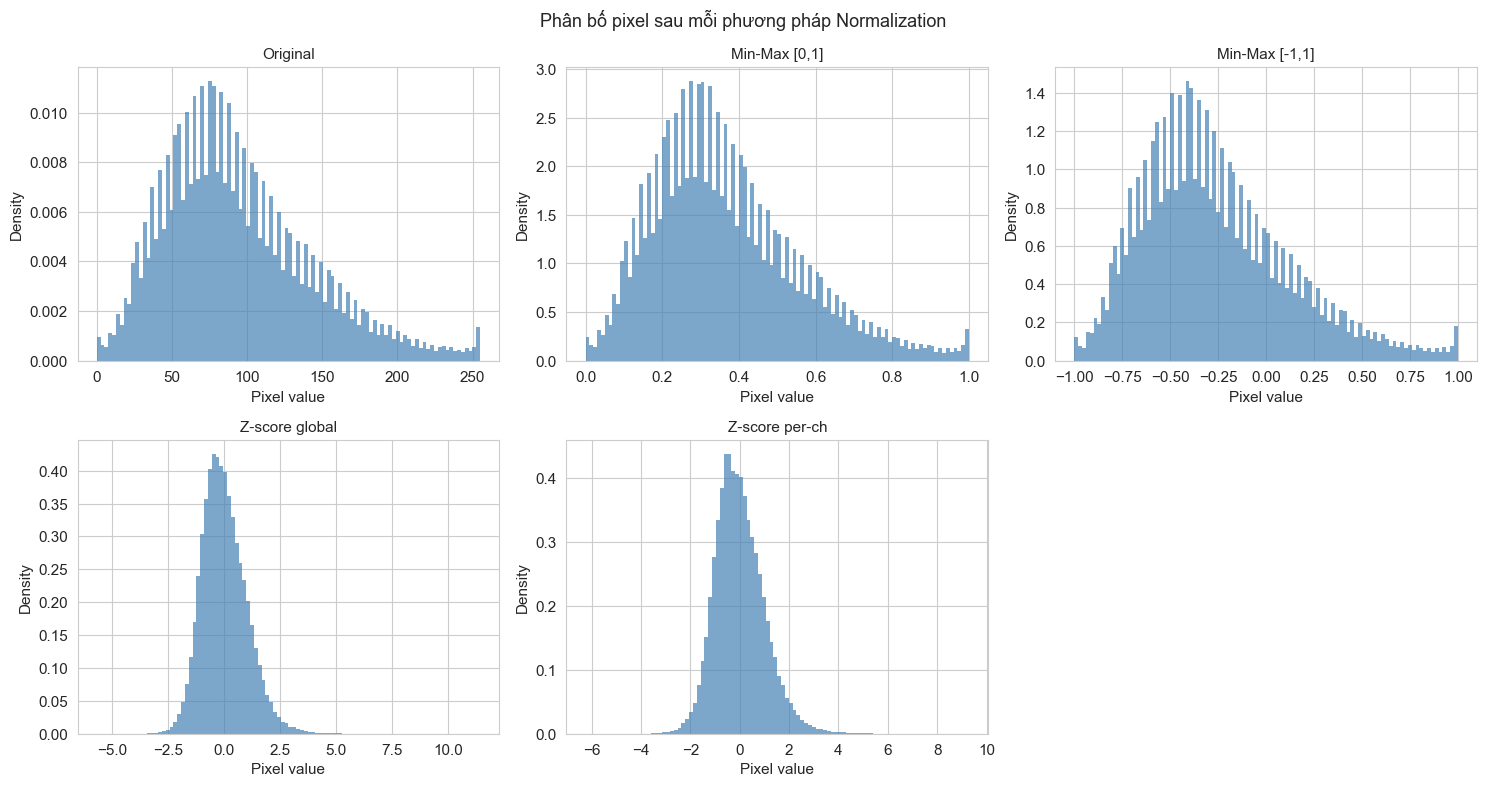

In [261]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for idx, (method, px) in enumerate(norm_pixels.items()):
    row, col = divmod(idx, 3)
    px_plot = np.random.choice(px, 200000, replace=False) if len(px) > 200000 else px
    axes[row][col].hist(px_plot, bins=100, color='steelblue', alpha=0.7, density=True, edgecolor='none')
    axes[row][col].set_title(method, fontsize=11)
    axes[row][col].set_xlabel("Pixel value")
    axes[row][col].set_ylabel("Density")
if len(norm_pixels) < 6:
    axes[1][2].axis('off')
plt.suptitle("Phân bố pixel sau mỗi phương pháp Normalization", fontsize=13)
plt.tight_layout()
plt.show()

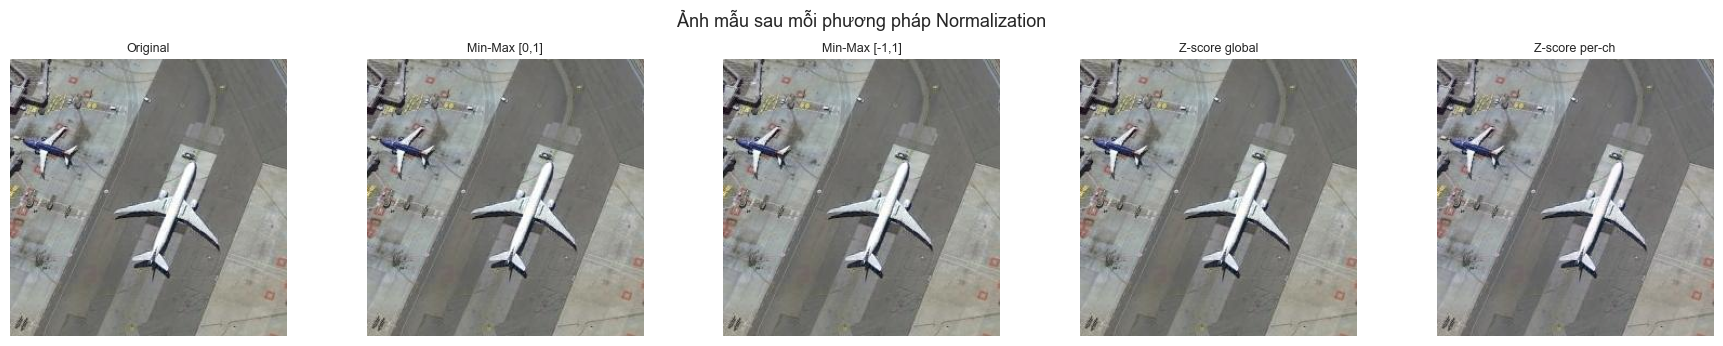

In [262]:
# Ảnh mẫu trước/sau normalization
sample_img = norm_samples[0][0]
fig, axes = plt.subplots(1, len(NORM_METHODS), figsize=(18, 3.5))
for idx, (method, norm_fn) in enumerate(NORM_METHODS.items()):
    normed = norm_fn(sample_img)
    # Rescale to [0,1] cho hiển thị
    display = (normed - normed.min()) / (normed.max() - normed.min() + 1e-8)
    display = np.clip(display, 0, 1)
    axes[idx].imshow(display)
    axes[idx].set_title(method, fontsize=9)
    axes[idx].axis('off')
plt.suptitle("Ảnh mẫu sau mỗi phương pháp Normalization", fontsize=13)
plt.tight_layout()
plt.show()

### Ablation: k-NN accuracy theo normalization

In [263]:
# k-NN accuracy theo normalization (resize 64x64, 45 lớp)
norm_knn_samples = load_sample(n_per_class=50)

norm_knn_results = {}
for method_name, norm_fn in NORM_METHODS.items():
    X, y = [], []
    for img, cls in norm_knn_samples:
        resized = cv2.resize(img, (64, 64))
        normed = norm_fn(resized)
        X.append(normed.reshape(-1))
        y.append(cls)
    X, y = np.array(X), np.array(y)
    
    knn = KNeighborsClassifier(n_neighbors=5)
    scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
    norm_knn_results[method_name] = (scores.mean(), scores.std())
    print(f"  {method_name}: accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})")

  Original: accuracy = 0.0902 (+/- 0.0027)
  Min-Max [0,1]: accuracy = 0.0902 (+/- 0.0027)
  Min-Max [-1,1]: accuracy = 0.0902 (+/- 0.0027)
  Z-score global: accuracy = 0.1013 (+/- 0.0064)
  Z-score per-ch: accuracy = 0.0471 (+/- 0.0095)


**Kết luận Normalization:**

| Phương pháp | KS stat | Mean | Std | k-NN Accuracy |
|-------------|---------|------|-----|---------------|
| Original | 0.000 | 93.74 | 48.78 | $0.090 \pm 0.003$ |
| Min-Max [0,1] | 0.998 | 0.37 | 0.19 | $0.090 \pm 0.003$ |
| Min-Max [-1,1] | 0.998 | -0.27 | 0.38 | $0.090 \pm 0.003$ |
| Z-score global | 0.996 | 0.002 | 1.00 | $0.101 \pm 0.006$ |
| Z-score per-ch | 0.996 | 0.001 | 0.99 | $0.047 \pm 0.010$ |

- **Bác bỏ $H_0$** cho tất cả 4 phương pháp: phân phối pixel thay đổi hoàn toàn sau chuẩn hóa
  - KS stat $\approx 1.0$, $p \approx 0$ - phân phối trước và sau khác biệt cực lớn (expected)
  - Levene test cũng reject ($p \approx 0$) - variance khác nhau giữa các phương pháp
- Min-Max [0,1] và [-1,1] chỉ thay đổi scale, **không thay đổi hình dạng phân bố**
  - k-NN accuracy giống hệt Original (0.090) vì k-NN dựa trên khoảng cách tỉ lệ thuận
- Z-score global cho accuracy cao nhất (0.101)
  - Đưa mean $\approx 0$, std $\approx 1$, phân bố gần đối xứng hơn
- Z-score per-channel cho accuracy **thấp nhất** (0.047)
  - Chuẩn hóa riêng từng kênh phá hủy quan hệ tương đối giữa R, G, B
  - Ảnh có cùng tỉ lệ R:G:B nhưng khác brightness sẽ trở nên giống nhau sau normalize
- **Lựa chọn: Z-score global** - accuracy cao nhất, phân bố gần chuẩn

---
## 4. Data Augmentation — Ablation Study (t-SNE)

Pipeline augmentation gồm **6 phép biến đổi** (≥5 theo yêu cầu):
Lật ngang · Lật dọc · Xoay · Cắt ngẫu nhiên · Nhiễu Gaussian · Điều chỉnh độ sáng/tương phản.
Đánh giá tác động qua t-SNE visualization: tập gốc vs tập đã augment.


In [264]:
def augment_hflip(img):
    """Lật ngang"""
    return cv2.flip(img, 1)

def augment_vflip(img):
    """Lật dọc"""
    return cv2.flip(img, 0)

def augment_rotate(img, angle=15):
    """Xoay ngẫu nhiên"""
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h))

def augment_crop(img, scale=0.8):
    """Cắt ngẫu nhiên"""
    h, w = img.shape[:2]
    new_h, new_w = int(h*scale), int(w*scale)
    top = np.random.randint(0, h - new_h + 1)
    left = np.random.randint(0, w - new_w + 1)
    cropped = img[top:top+new_h, left:left+new_w]
    return cv2.resize(cropped, (w, h))

def augment_gaussian_noise(img, sigma=25):
    """Thêm nhiễu Gaussian"""
    noise = np.random.normal(0, sigma, img.shape)
    noisy = img.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def augment_brightness_contrast(img, brightness=30, contrast=0.2):
    """Điều chỉnh độ sáng/tương phản"""
    img_f = img.astype(np.float32)
    img_f = img_f + np.random.uniform(-brightness, brightness)
    img_f = img_f * np.random.uniform(1-contrast, 1+contrast)
    return np.clip(img_f, 0, 255).astype(np.uint8)

AUGMENTATIONS = {
    'H-Flip': augment_hflip,
    'V-Flip': augment_vflip,
    'Rotation': augment_rotate,
    'Random Crop': augment_crop,
    'Gaussian Noise': augment_gaussian_noise,
    'Brightness/Contrast': augment_brightness_contrast
}
print(f"{len(AUGMENTATIONS)} phép augmentation: {list(AUGMENTATIONS.keys())}")

6 phép augmentation: ['H-Flip', 'V-Flip', 'Rotation', 'Random Crop', 'Gaussian Noise', 'Brightness/Contrast']


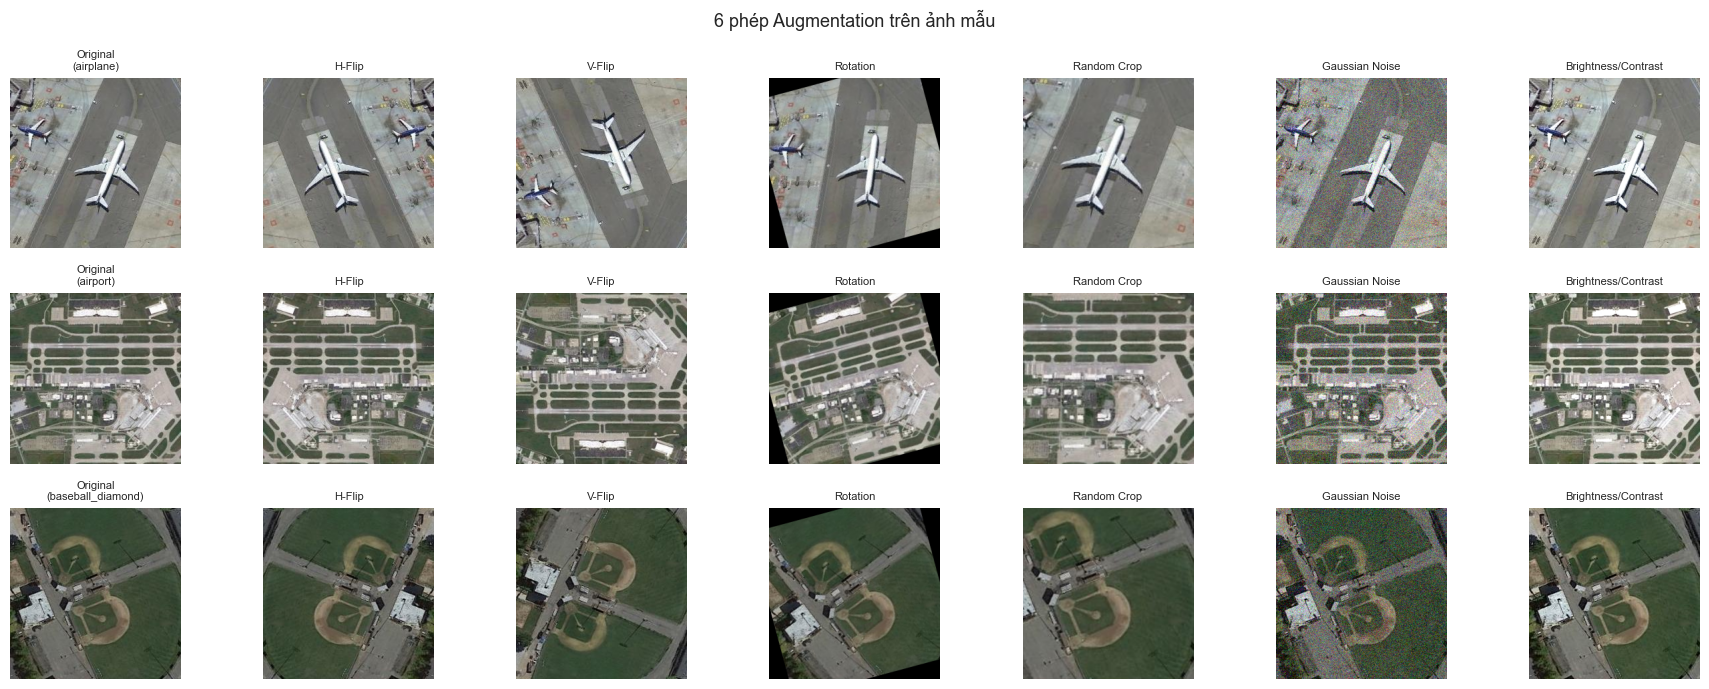

In [265]:
# Visual: ảnh trước/sau augmentation
vis_sample = load_sample(n_per_class=1)[:3]

fig, axes = plt.subplots(3, len(AUGMENTATIONS) + 1, figsize=(18, 7))
for row, (img, cls) in enumerate(vis_sample):
    axes[row][0].imshow(img)
    axes[row][0].set_title(f"Original\n({cls})", fontsize=8)
    axes[row][0].axis('off')
    for col, (aug_name, aug_fn) in enumerate(AUGMENTATIONS.items()):
        np.random.seed(42)
        augmented = aug_fn(img)
        axes[row][col+1].imshow(augmented)
        axes[row][col+1].set_title(aug_name, fontsize=8)
        axes[row][col+1].axis('off')
plt.suptitle(f"{len(AUGMENTATIONS)} phép Augmentation trên ảnh mẫu", fontsize=13)
plt.tight_layout()
plt.show()

### t-SNE: Feature space trước/sau augmentation

Chạy t-SNE với số lớp tăng dần (5, 10, 15, 20, 25, 30, 35, 40, 45) để quan sát
feature space thay đổi khi thêm lớp.

  5 lớp: done (100 samples)
  10 lớp: done (200 samples)
  15 lớp: done (300 samples)
  20 lớp: done (400 samples)
  25 lớp: done (500 samples)
  30 lớp: done (600 samples)
  35 lớp: done (700 samples)
  40 lớp: done (800 samples)
  45 lớp: done (900 samples)


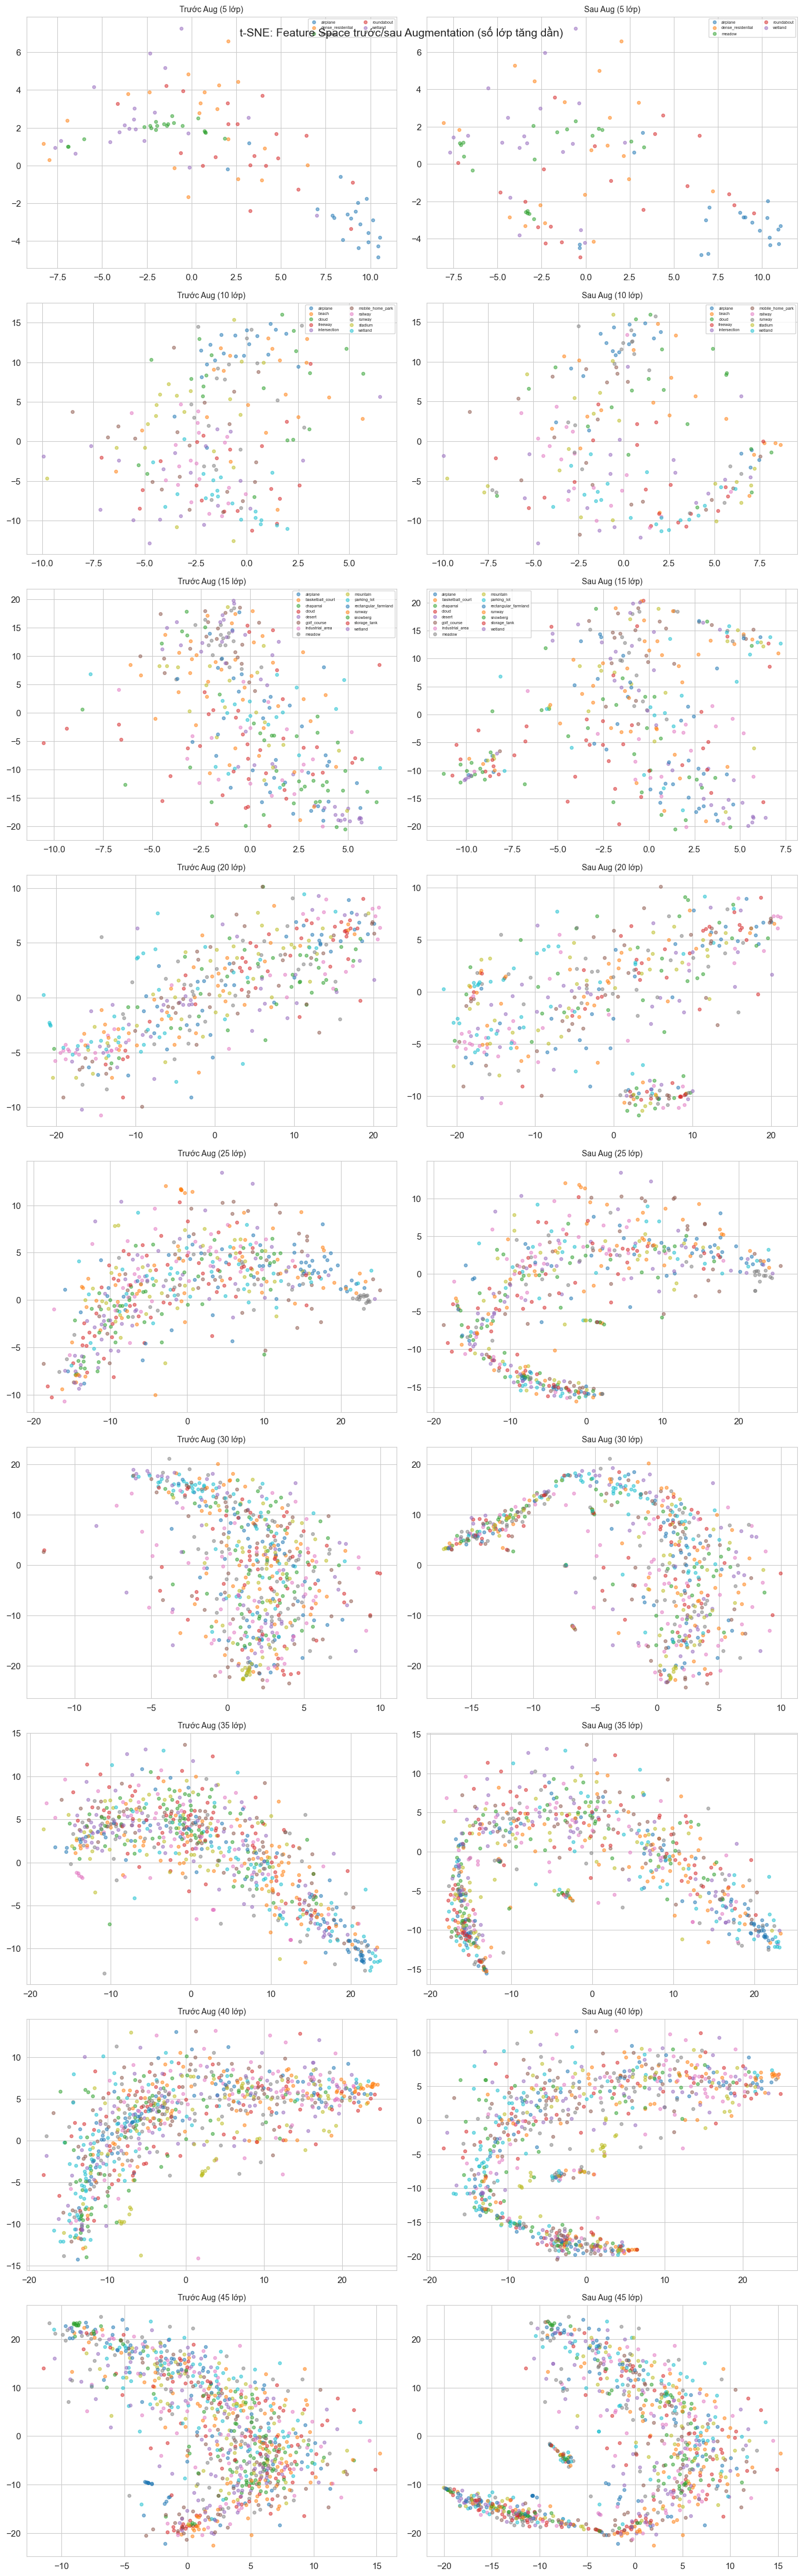

In [266]:
# t-SNE với số lớp tăng dần
n_class_list = [5, 10, 15, 20, 25, 30, 35, 40, 45]

def extract_feature(img):
    small = cv2.resize(img, (32, 32))
    return small.reshape(-1).astype(np.float32) / 255.0

fig, axes = plt.subplots(len(n_class_list), 2, figsize=(14, 5 * len(n_class_list)))

for row, n_cls in enumerate(n_class_list):
    # Chọn n_cls lớp cách đều
    cls_indices = np.linspace(0, len(classes) - 1, n_cls, dtype=int)
    selected_classes = [classes[i] for i in cls_indices]
    
    # Load samples
    tsne_samples = load_sample(n_per_class=20, target_classes=selected_classes)
    
    # Original features
    orig_features, orig_labels = [], []
    for img, cls in tsne_samples:
        orig_features.append(extract_feature(img))
        orig_labels.append(cls)
    
    # Augmented features (pipeline 2 phép ngẫu nhiên)
    aug_features, aug_labels = [], []
    np.random.seed(42)
    aug_fns = list(AUGMENTATIONS.values())
    for img, cls in tsne_samples:
        aug_img = img.copy()
        for fn in np.random.choice(aug_fns, 2, replace=False):
            aug_img = fn(aug_img)
        aug_features.append(extract_feature(aug_img))
        aug_labels.append(cls)
    
    X_orig = np.array(orig_features)
    X_aug = np.array(aug_features)
    y_orig = np.array(orig_labels)
    y_aug = np.array(aug_labels)
    
    # t-SNE
    X_combined = np.vstack([X_orig, X_aug])
    is_aug = np.array([0]*len(X_orig) + [1]*len(X_aug))
    labels_combined = np.concatenate([y_orig, y_aug])
    
    tsne = TSNE(n_components=2, perplexity=min(30, len(X_orig)-1), random_state=42, max_iter=1000)
    X_tsne = tsne.fit_transform(X_combined)
    
    # Plot
    for col, (mask_val, title) in enumerate([(0, "Trước Aug"), (1, "Sau Aug")]):
        mask = is_aug == mask_val
        for cls in selected_classes:
            cls_mask = (labels_combined == cls) & mask
            axes[row][col].scatter(X_tsne[cls_mask, 0], X_tsne[cls_mask, 1], alpha=0.5, s=15, label=cls)
        axes[row][col].set_title(f"{title} ({n_cls} lớp)", fontsize=10)
        if n_cls <= 15:
            axes[row][col].legend(fontsize=5, ncol=2)
    
    print(f"  {n_cls} lớp: done ({len(X_orig)} samples)")

plt.suptitle("t-SNE: Feature Space trước/sau Augmentation (số lớp tăng dần)", fontsize=14)
plt.tight_layout()
plt.show()

### Kiểm định: Augmentation có tăng diversity?

In [267]:
# Kiểm định variance trước/sau augmentation (toàn bộ 45 lớp)
test_samples = load_sample(n_per_class=20)

# Original features
X_test_orig, y_test = [], []
for img, cls in test_samples:
    X_test_orig.append(extract_feature(img))
    y_test.append(cls)

# Augmented features
X_test_aug = []
np.random.seed(42)
aug_fns = list(AUGMENTATIONS.values())
for img, cls in test_samples:
    aug_img = img.copy()
    for fn in np.random.choice(aug_fns, 2, replace=False):
        aug_img = fn(aug_img)
    X_test_aug.append(extract_feature(aug_img))

X_test_orig = np.array(X_test_orig)
X_test_aug = np.array(X_test_aug)
y_test = np.array(y_test)

print(f"{'Class':<25} {'Original':>10} {'Augmented':>10} {'Change':>10}")
print("-" * 57)

orig_vars, aug_vars = [], []
for cls in classes:
    mask = y_test == cls
    var_o = np.var(X_test_orig[mask], axis=0).mean()
    var_a = np.var(X_test_aug[mask], axis=0).mean()
    change = (var_a - var_o) / (var_o + 1e-8) * 100
    orig_vars.append(var_o)
    aug_vars.append(var_a)
    print(f"{cls:<25} {var_o:>10.4f} {var_a:>10.4f} {change:>+9.1f}%")

t_stat, t_p = stats.ttest_rel(orig_vars, aug_vars)
w_stat, w_p = stats.wilcoxon(orig_vars, aug_vars, alternative='less')
diff = np.array(aug_vars) - np.array(orig_vars)
cohens_d = diff.mean() / (diff.std(ddof=1) + 1e-8)

print(f"\nPaired t-test: t={t_stat:.3f}, p={t_p:.4f}")
print(f"Wilcoxon: W={w_stat:.1f}, p={w_p:.4f}")
print(f"Cohen's d = {cohens_d:.3f}")
print(f"Lớp có variance tăng: {sum(d > 0 for d in diff)}/{len(diff)}")

Class                       Original  Augmented     Change
---------------------------------------------------------
airplane                      0.0251     0.0294     +17.0%
airport                       0.0334     0.0357      +6.9%
baseball_diamond              0.0191     0.0241     +26.4%
basketball_court              0.0210     0.0265     +26.3%
beach                         0.0386     0.0410      +6.3%
bridge                        0.0187     0.0222     +18.7%
chaparral                     0.0377     0.0427     +13.2%
church                        0.0419     0.0480     +14.4%
circular_farmland             0.0160     0.0216     +34.5%
cloud                         0.0559     0.0599      +7.2%
commercial_area               0.0306     0.0361     +18.0%
dense_residential             0.0338     0.0365      +8.1%
desert                        0.0201     0.0313     +55.3%
forest                        0.0066     0.0077     +16.6%
freeway                       0.0202     0.0287     +42.0

### Ablation: k-NN accuracy trước/sau augmentation

In [268]:
# k-NN: so sánh accuracy trước/sau augmentation
aug_knn_samples = load_sample(n_per_class=30)

# Original features
X_orig_knn, y_orig_knn = [], []
for img, cls in aug_knn_samples:
    resized = cv2.resize(img, (64, 64))
    X_orig_knn.append(resized.reshape(-1).astype(np.float32) / 255.0)
    y_orig_knn.append(cls)

# Augmented features (thêm 1 bản augmented cho mỗi ảnh)
X_aug_knn, y_aug_knn = [], []
np.random.seed(42)
aug_fns = list(AUGMENTATIONS.values())
for img, cls in aug_knn_samples:
    resized = cv2.resize(img, (64, 64))
    # Giữ ảnh gốc
    X_aug_knn.append(resized.reshape(-1).astype(np.float32) / 255.0)
    y_aug_knn.append(cls)
    # Thêm bản augmented
    aug_img = img.copy()
    for fn in np.random.choice(aug_fns, 2, replace=False):
        aug_img = fn(aug_img)
    aug_resized = cv2.resize(aug_img, (64, 64))
    X_aug_knn.append(aug_resized.reshape(-1).astype(np.float32) / 255.0)
    y_aug_knn.append(cls)

X_orig_knn, y_orig_knn = np.array(X_orig_knn), np.array(y_orig_knn)
X_aug_knn, y_aug_knn = np.array(X_aug_knn), np.array(y_aug_knn)

knn = KNeighborsClassifier(n_neighbors=5)

scores_orig = cross_val_score(knn, X_orig_knn, y_orig_knn, cv=5, scoring='accuracy')
scores_aug = cross_val_score(knn, X_aug_knn, y_aug_knn, cv=5, scoring='accuracy')

print(f"Trước augmentation: {scores_orig.mean():.4f} (+/- {scores_orig.std():.4f})  [{len(X_orig_knn)} samples]")
print(f"Sau augmentation:   {scores_aug.mean():.4f} (+/- {scores_aug.std():.4f})  [{len(X_aug_knn)} samples]")
print(f"Thay đổi: {(scores_aug.mean() - scores_orig.mean()) / scores_orig.mean() * 100:+.1f}%")

Trước augmentation: 0.0978 (+/- 0.0050)  [1350 samples]
Sau augmentation:   0.0841 (+/- 0.0098)  [2700 samples]
Thay đổi: -14.0%


**Kết luận Augmentation:**

- **Bác bỏ $H_0$**: Augmentation làm tăng intra-class variance có ý nghĩa thống kê
  - Paired t-test: $t = -10.700$, $p \approx 0$
  - Wilcoxon: $W = 8.0$, $p \approx 0$
  - Cohen's d $= 1.595$ (effect size rất lớn)
- **44/45 lớp** có variance tăng sau augmentation
  - Duy nhất `railway` giảm nhẹ (-8.0%)
  - Lớp tăng mạnh nhất: `desert` (+55.3%), `terrace` (+49.2%), `freeway` (+42.0%), `wetland` (+42.6%)
  - Lớp tăng ít nhất: `mobile_home_park` (+0.1%), `mountain` (+0.3%)
- **k-NN Ablation** (1-NN, resize 64×64, raw pixel):

  | | Accuracy | Samples |
  |---|---|---|
  | Trước augmentation | $0.0978 \pm 0.0050$ | 1350 |
  | Sau augmentation | $0.0841 \pm 0.0098$ | 2700 |
  | Thay đổi | **−14.0%** | — |

  > Giảm accuracy là **expected**: raw-pixel k-NN không bất biến với phép biến đổi hình học/màu sắc. Augmentation thêm ảnh biến đổi (flip, rotate, noise…) làm tăng intra-class distance trong pixel space → k-NN khó phân loại hơn. Với feature extractor học được (CNN), augmentation sẽ cải thiện accuracy.
- t-SNE visualization:
  - Với 5-15 lớp: cluster rõ ràng, sau augmentation các cluster mở rộng nhưng vẫn tách biệt
  - Với 30-45 lớp: cluster chồng chéo nhiều hơn (expected với raw pixel features)
  - Augmentation làm feature space đa dạng hơn mà không phá vỡ cấu trúc lớp
- **Pipeline 6 phép** (H-Flip, V-Flip, Rotation, Random Crop, Gaussian Noise, Brightness/Contrast) hiệu quả cho tăng diversity

---
## 5. [Nâng cao] PCA đặc trưng ảnh

Flatten ảnh grayscale 64×64 thành vector 4096-D, chạy PCA trên toàn bộ 45 lớp
(50 ảnh/lớp = 2250 ảnh) để tìm eigenimages và xem các lớp có phân tách được trên
không gian PCA hay không.

- **$H_0$:** Các lớp không phân tách được trên PC1 (PC1 mean không khác biệt giữa lớp).
- **$H_1$:** Ít nhất một cặp lớp phân tách được trên PC1.

In [ ]:
PCA_SIZE = 64
N_PCA_SAMPLE = 50

pca_data, pca_labels = [], []
for cls in tqdm(classes, desc="Loading"):
    paths = glob.glob(os.path.join(TRAIN_DIR, cls, "*.jpg"))
    np.random.seed(42)
    chosen = np.random.choice(paths, min(N_PCA_SAMPLE, len(paths)), replace=False)
    for p in chosen:
        img = cv2.imread(p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img = cv2.resize(img, (PCA_SIZE, PCA_SIZE))
        pca_data.append(img.ravel().astype(np.float32) / 255.0)
        pca_labels.append(cls)

X_pca = np.array(pca_data)
y_pca = np.array(pca_labels)
print(f"Ma trận PCA: {X_pca.shape}")

In [ ]:
pca = PCA(n_components=min(100, X_pca.shape[0]-1))
X_pca_transformed = pca.fit_transform(X_pca)

cum_var = np.cumsum(pca.explained_variance_ratio_)
n90 = np.argmax(cum_var >= 0.90) + 1 if cum_var[-1] >= 0.90 else ">100"
n95 = np.argmax(cum_var >= 0.95) + 1 if cum_var[-1] >= 0.95 else ">100"
n99 = np.argmax(cum_var >= 0.99) + 1 if cum_var[-1] >= 0.99 else ">100"

print(f"Components cho 90%: {n90}")
print(f"Components cho 95%: {n95}")
print(f"Components cho 99%: {n99}")

### Scree Plot & Cumulative Variance

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 31), pca.explained_variance_ratio_[:30], color='#4C72B0', alpha=0.8)
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree Plot (top 30)")

axes[1].plot(range(1, len(cum_var)+1), cum_var, color='#4C72B0', linewidth=2)
axes[1].axhline(0.95, color='red', linestyle='--', alpha=0.6, label='95%')
axes[1].axhline(0.90, color='orange', linestyle='--', alpha=0.6, label='90%')
if isinstance(n95, int): axes[1].axvline(n95, color='red', linestyle=':', alpha=0.4)
axes[1].set_xlabel("Số components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()
plt.tight_layout()
plt.show()

### Eigenimages (Top 10 Principal Components)

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
for idx, ax in enumerate(axes.ravel()):
    eigenimg = pca.components_[idx].reshape(PCA_SIZE, PCA_SIZE)
    ax.imshow(eigenimg, cmap='gray')
    ax.set_title(f"PC{idx+1} ({pca.explained_variance_ratio_[idx]*100:.1f}%)", fontsize=9)
    ax.axis('off')
plt.suptitle("Top 10 Eigenimages", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Mean image
mean_img = X_pca.mean(axis=0).reshape(PCA_SIZE, PCA_SIZE)
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(mean_img, cmap='gray')
ax.set_title("Mean Image (toàn dataset)")
ax.axis('off')
plt.tight_layout()
plt.show()

### 2D Projection - Chọn 10 lớp đại diện

Từ kết quả PCA, tính PC1 mean cho mỗi lớp, sắp xếp,
chọn 5 lớp PC1 thấp nhất + 5 cao nhất để minh họa sự phân tách.

In [ ]:
pc1_per_class = {}
for cls in classes:
    mask = y_pca == cls
    pc1_per_class[cls] = X_pca_transformed[mask, 0].mean()

sorted_by_pc1 = sorted(pc1_per_class, key=pc1_per_class.get)
REPR_CLASSES = sorted_by_pc1[:5] + sorted_by_pc1[-5:]

for cls in REPR_CLASSES:
    print(f"  {cls}: PC1 mean = {pc1_per_class[cls]:.3f}")

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(REPR_CLASSES)))

for cls, color in zip(REPR_CLASSES, colors):
    mask = y_pca == cls
    ax.scatter(X_pca_transformed[mask, 0], X_pca_transformed[mask, 1],
               c=[color], label=cls, alpha=0.5, s=15)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA 2D Projection (5 PC1 thấp nhất + 5 cao nhất)")
ax.legend(fontsize=8, loc='best', ncol=2)
plt.tight_layout()
plt.show()

### 3D PCA Projection

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
colors_3d = plt.cm.tab10(np.linspace(0, 1, len(REPR_CLASSES)))

for cls, color in zip(REPR_CLASSES, colors_3d):
    mask = y_pca == cls
    ax.scatter(X_pca_transformed[mask, 0],
               X_pca_transformed[mask, 1],
               X_pca_transformed[mask, 2],
               c=[color], label=cls, alpha=0.6, s=15)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)")
ax.set_title("PCA 3D Projection (10 lớp đại diện)")
ax.legend(fontsize=8, loc="upper left", ncol=2)
plt.tight_layout()
plt.show()


### t-SNE Projection

t-SNE (non-linear) giữ cấu trúc local tốt hơn PCA — dùng 50 PCA components làm input để giảm nhiễu và tăng tốc.
Perplexity=30 (~1/3 số mẫu mỗi lớp).


In [ ]:
from sklearn.manifold import TSNE

print("Running t-SNE (perplexity=30, n_iter=1000)...")
tsne_model = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne_model.fit_transform(X_pca_transformed[:, :50])
print("Done.")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: all 45 classes
colors_45 = plt.cm.nipy_spectral(np.linspace(0, 0.9, len(classes)))
for cls, color in zip(classes, colors_45):
    mask = y_pca == cls
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=[color], alpha=0.5, s=10)
axes[0].set_title("t-SNE: Tất cả 45 lớp")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")

# Right: 10 representative highlighted
axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c="lightgray", alpha=0.15, s=8)
colors_repr = plt.cm.tab10(np.linspace(0, 1, len(REPR_CLASSES)))
for cls, color in zip(REPR_CLASSES, colors_repr):
    mask = y_pca == cls
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=[color], label=cls, alpha=0.8, s=20)
axes[1].set_title("t-SNE: 10 lớp đại diện highlighted")
axes[1].set_xlabel("t-SNE 1")
axes[1].legend(fontsize=8, ncol=2)

plt.suptitle("t-SNE 2D (input: 50 PCA components, perplexity=30)", fontsize=13)
plt.tight_layout()
plt.show()


**Nhận xét t-SNE so với PCA:**

- **PCA 2D** (linear): giữ cấu trúc global — lớp phân tán theo độ sáng PC1. Desert/snowberg tách xa forest/wetland.
- **t-SNE** (non-linear): giữ cấu trúc local — lớp có texture đặc trưng (desert, snowberg, runway) tạo cluster rõ hơn.
- Cả hai xác nhận: **độ sáng tổng thể (PC1=42.6%)** là yếu tố phân biệt chính; lớp urban phức tạp (harbor, dense_residential) overlap nhiều hơn.


### Kiểm định: Các lớp phân tách trên PC1?

In [ ]:
groups_pc1 = [X_pca_transformed[y_pca == c, 0] for c in classes]

# Normality
print("Normality (Shapiro-Wilk, 5 lớp mẫu):")
for cls in classes[:5]:
    vals = X_pca_transformed[y_pca == cls, 0]
    w, p = stats.shapiro(vals)
    print(f"  {cls}: W={w:.4f}, p={p:.4f}")

# Levene
lev_s, lev_p = stats.levene(*groups_pc1)
print(f"\nLevene: stat={lev_s:.2f}, p={lev_p:.2e}")

# ANOVA + Kruskal
f_val, p_val = stats.f_oneway(*groups_pc1)
h_val, kw_p = stats.kruskal(*groups_pc1)
print(f"\nANOVA: F={f_val:.2f}, p={p_val:.2e}")
print(f"Kruskal-Wallis: H={h_val:.2f}, p={kw_p:.2e}")

# Eta²
ss_between = sum(len(g) * (g.mean() - X_pca_transformed[:, 0].mean())**2 for g in groups_pc1)
ss_total = sum((x - X_pca_transformed[:, 0].mean())**2 for x in X_pca_transformed[:, 0])
eta_sq = ss_between / ss_total
print(f"\nEta² = {eta_sq:.3f}")

**Kết luận PCA:**

PC1 giải thích **42.6%** variance (dominant), trong khi 100 components đầu chỉ đạt ~75% —
dữ liệu ảnh vệ tinh phân tán trên nhiều chiều (cần >100 components để đạt 90%).
Eigenimages cho thấy PC1 nắm bắt pattern độ sáng tổng thể, PC2-PC3 nắm bắt cạnh và texture.

Levene p=1.41e-29 → phương sai không đồng nhất giữa lớp → ưu tiên Kruskal-Wallis:
H=982.19, p≈0 (ANOVA F=50.37, p≈0) → bác bỏ $.
**Eta² = 0.501** (large effect) — các lớp **phân tách được** trên PC1 ở mức độ trung bình-lớn,
xác nhận PC1 mang thông tin phân biệt lớp cảnh.

---
## 6. [Nâng cao] Edge Detection (Sobel & Canny)

Tính **edge density** (Canny) và **Sobel magnitude** cho 45 lớp
để xem loại cảnh nào có cạnh/texture phức tạp.

- **$H_0$:** Edge density không khác biệt giữa 45 lớp.
- **$H_1$:** Ít nhất 1 cặp lớp có edge density khác biệt.

### Edge Density - Toàn bộ 45 lớp

In [ ]:
EDGE_SAMPLE = 30

edge_data = []
for cls in tqdm(classes, desc="Edge density"):
    paths = glob.glob(os.path.join(TRAIN_DIR, cls, "*.jpg"))
    np.random.seed(42)
    chosen = np.random.choice(paths, min(EDGE_SAMPLE, len(paths)), replace=False)
    for p in chosen:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        edges = cv2.Canny(img, 80, 160)
        density = edges.mean() / 255.0
        sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
        sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
        sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2).mean()
        edge_data.append({'class': cls, 'canny_density': density, 'sobel_magnitude': sobel_mag})

df_edge = pd.DataFrame(edge_data)
print(f"Canny density: mean={df_edge['canny_density'].mean():.4f}, std={df_edge['canny_density'].std():.4f}")
print(f"Sobel magnitude: mean={df_edge['sobel_magnitude'].mean():.1f}, std={df_edge['sobel_magnitude'].std():.1f}")

In [ ]:
class_edge = df_edge.groupby('class')['canny_density'].mean().sort_values()

print("Top 5 edge density cao nhất:")
for cls, val in class_edge.tail(5).items():
    print(f"  {cls}: {val:.4f}")
print("\nTop 5 edge density thấp nhất:")
for cls, val in class_edge.head(5).items():
    print(f"  {cls}: {val:.4f}")

### Demo Edge Detection

Chọn 5 lớp đại diện từ sorted edge density: 2 thấp nhất, 1 trung vị, 2 cao nhất.

In [ ]:
sorted_edge_classes = class_edge.index.tolist()
ne = len(sorted_edge_classes)
demo_pick = [0, 1, ne // 2, ne - 2, ne - 1]
demo_classes = [sorted_edge_classes[i] for i in demo_pick]

for cls in demo_classes:
    print(f"  {cls}: canny density = {class_edge[cls]:.4f}")

In [ ]:
demo_samples = load_sample(n_per_class=1, target_classes=demo_classes)

fig, axes = plt.subplots(5, 4, figsize=(14, 16))
axes[0][0].set_title("Original", fontsize=10)
axes[0][1].set_title("Sobel Combined", fontsize=10)
axes[0][2].set_title("Canny (low)", fontsize=10)
axes[0][3].set_title("Canny (high)", fontsize=10)

for row, (img, cls) in enumerate(demo_samples):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    axes[row][0].imshow(img)
    axes[row][0].set_ylabel(cls, fontsize=10, rotation=0, labelpad=60)
    axes[row][0].axis('off')

    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel_combined = np.sqrt(sobel_x**2 + sobel_y**2)
    sobel_combined = np.clip(sobel_combined / sobel_combined.max() * 255, 0, 255).astype(np.uint8)
    axes[row][1].imshow(sobel_combined, cmap='gray')
    axes[row][1].axis('off')

    canny_low = cv2.Canny(gray, 50, 100)
    axes[row][2].imshow(canny_low, cmap='gray')
    axes[row][2].axis('off')

    canny_high = cv2.Canny(gray, 100, 200)
    axes[row][3].imshow(canny_high, cmap='gray')
    axes[row][3].axis('off')

plt.suptitle("Edge Detection: Sobel vs Canny", fontsize=14)
plt.tight_layout()
plt.show()

### So sánh: Sobel (ksize=3 vs ksize=5) và Prewitt (raw vs smooth)

| Bộ lọc | Tham số 1 | Tham số 2 |
|--------|-----------|-----------|
| **Sobel** | ksize=3 | ksize=5 |
| **Prewitt** | Ảnh gốc (raw) | Gaussian blur trước (σ=1) |
| **Canny** | thresholds=50/80 | thresholds=100/200 |


In [ ]:
prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
prewitt_y = np.array([[-1,-1,-1], [ 0, 0, 0], [ 1, 1, 1]], dtype=np.float32)

def norm_edge(arr):
    m = arr.max()
    return np.clip(arr / m * 255, 0, 255).astype(np.uint8) if m > 0 else np.zeros_like(arr, dtype=np.uint8)

fig, axes = plt.subplots(5, 6, figsize=(16, 16))
col_titles = ["Original", "Sobel k=3", "Sobel k=5", "Prewitt (raw)", "Prewitt (smooth)", "Canny (50/80)"]
for ci, t in enumerate(col_titles):
    axes[0][ci].set_title(t, fontsize=9)

for row, (img, cls) in enumerate(demo_samples):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    axes[row][0].imshow(img)
    axes[row][0].set_ylabel(cls, fontsize=8, rotation=0, labelpad=70)
    axes[row][0].axis("off")

    # Sobel k=3
    s3 = norm_edge(np.sqrt(cv2.Sobel(gray,cv2.CV_64F,1,0,ksize=3)**2
                         + cv2.Sobel(gray,cv2.CV_64F,0,1,ksize=3)**2))
    axes[row][1].imshow(s3, cmap="gray"); axes[row][1].axis("off")

    # Sobel k=5
    s5 = norm_edge(np.sqrt(cv2.Sobel(gray,cv2.CV_64F,1,0,ksize=5)**2
                         + cv2.Sobel(gray,cv2.CV_64F,0,1,ksize=5)**2))
    axes[row][2].imshow(s5, cmap="gray"); axes[row][2].axis("off")

    # Prewitt raw
    px  = cv2.filter2D(gray.astype(np.float32), -1, prewitt_x)
    py_ = cv2.filter2D(gray.astype(np.float32), -1, prewitt_y)
    axes[row][3].imshow(norm_edge(np.sqrt(px**2 + py_**2)), cmap="gray"); axes[row][3].axis("off")

    # Prewitt smooth
    gs  = cv2.GaussianBlur(gray, (3,3), 1)
    px2 = cv2.filter2D(gs.astype(np.float32), -1, prewitt_x)
    py2 = cv2.filter2D(gs.astype(np.float32), -1, prewitt_y)
    axes[row][4].imshow(norm_edge(np.sqrt(px2**2 + py2**2)), cmap="gray"); axes[row][4].axis("off")

    # Canny (50, 80)
    axes[row][5].imshow(cv2.Canny(gray, 50, 80), cmap="gray"); axes[row][5].axis("off")

plt.suptitle("So sánh: Sobel (k=3, k=5) / Prewitt (raw, smooth) / Canny (50/80)", fontsize=13)
plt.tight_layout()
plt.show()


### Edge Density: So sánh 6 phương pháp + ANOVA

Binarize gradient magnitude với ngưỡng T=30 để tính tỉ lệ pixel cạnh trên toàn bộ 45 lớp.


In [ ]:
prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
prewitt_y = np.array([[-1,-1,-1], [ 0, 0, 0], [ 1, 1, 1]], dtype=np.float32)
THRESH = 30

multi_edge_data = []
for cls in tqdm(classes, desc="Multi-method edge"):
    paths = glob.glob(os.path.join(TRAIN_DIR, cls, "*.jpg"))
    np.random.seed(42)
    chosen = np.random.choice(paths, min(EDGE_SAMPLE, len(paths)), replace=False)
    for p in chosen:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        s3  = np.sqrt(cv2.Sobel(img,cv2.CV_64F,1,0,ksize=3)**2 + cv2.Sobel(img,cv2.CV_64F,0,1,ksize=3)**2)
        s5  = np.sqrt(cv2.Sobel(img,cv2.CV_64F,1,0,ksize=5)**2 + cv2.Sobel(img,cv2.CV_64F,0,1,ksize=5)**2)
        px  = cv2.filter2D(img.astype(np.float32), -1, prewitt_x)
        py_ = cv2.filter2D(img.astype(np.float32), -1, prewitt_y)
        pw  = np.sqrt(px**2 + py_**2)
        gs  = cv2.GaussianBlur(img, (3,3), 1)
        px2 = cv2.filter2D(gs.astype(np.float32), -1, prewitt_x)
        py2 = cv2.filter2D(gs.astype(np.float32), -1, prewitt_y)
        pw2 = np.sqrt(px2**2 + py2**2)
        multi_edge_data.append({"class": cls,
            "sobel_k3":      (s3  > THRESH).mean(),
            "sobel_k5":      (s5  > THRESH).mean(),
            "prewitt_raw":   (pw  > THRESH).mean(),
            "prewitt_smooth":(pw2 > THRESH).mean(),
            "canny_50_80":   cv2.Canny(img,  50,  80).mean() / 255.0,
            "canny_100_200": cv2.Canny(img, 100, 200).mean() / 255.0})
df_multi = pd.DataFrame(multi_edge_data)

methods = ["sobel_k3","sobel_k5","prewitt_raw","prewitt_smooth","canny_50_80","canny_100_200"]
print(f"{'Method':<22} {'F':>8} {'p':>12} {'Eta2':>7}  Ket luan")
print("-" * 65)
for m in methods:
    grps  = [df_multi[df_multi["class"]==c][m].values for c in classes]
    f_val, p_val = stats.f_oneway(*grps)
    ss_b  = sum(len(g)*(g.mean()-df_multi[m].mean())**2 for g in grps)
    ss_t  = ((df_multi[m] - df_multi[m].mean())**2).sum()
    eta2  = ss_b / ss_t
    sig   = "Co y nghia" if p_val < 0.05 else "Khong"
    print(f"{m:<22} {f_val:>8.2f} {p_val:>12.2e} {eta2:>7.3f}  {sig}")


In [ ]:
# Boxplot top/bottom
top_bottom_edge = list(class_edge.index[:7]) + list(class_edge.index[-7:])
df_edge_sub = df_edge[df_edge['class'].isin(top_bottom_edge)]
order_edge = class_edge[class_edge.index.isin(top_bottom_edge)].index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df_edge_sub, x='class', y='canny_density', order=order_edge,
            ax=axes[0], palette='RdYlGn_r')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=8)
axes[0].set_title("Canny Edge Density (7 thấp nhất + 7 cao nhất)")

class_sobel = df_edge.groupby('class')['sobel_magnitude'].mean().sort_values()
tb_sobel = list(class_sobel.index[:7]) + list(class_sobel.index[-7:])
df_sobel_sub = df_edge[df_edge['class'].isin(tb_sobel)]
order_sobel = class_sobel[class_sobel.index.isin(tb_sobel)].index.tolist()
sns.boxplot(data=df_sobel_sub, x='class', y='sobel_magnitude', order=order_sobel,
            ax=axes[1], palette='RdYlGn_r')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=8)
axes[1].set_title("Sobel Magnitude (7 thấp nhất + 7 cao nhất)")
plt.tight_layout()
plt.show()

### Kiểm định: Edge density & Correlation

In [ ]:
edge_groups = [df_edge[df_edge['class']==c]['canny_density'].values for c in classes]

lev_s, lev_p = stats.levene(*edge_groups)
f_edge, p_edge = stats.f_oneway(*edge_groups)
h_edge, kw_p_edge = stats.kruskal(*edge_groups)

ss_b = sum(len(g)*(g.mean() - df_edge['canny_density'].mean())**2 for g in edge_groups)
ss_t = sum((x - df_edge['canny_density'].mean())**2 for g in edge_groups for x in g)
eta2 = ss_b / ss_t

print(f"Levene: stat={lev_s:.2f}, p={lev_p:.2e}")
print(f"ANOVA:  F={f_edge:.2f}, p={p_edge:.2e}")
print(f"Kruskal: H={h_edge:.2f}, p={kw_p_edge:.2e}")
print(f"Eta² = {eta2:.3f}")

In [ ]:
# Correlation: Pearson + Spearman
r_pearson, p_pearson = stats.pearsonr(df_edge['canny_density'], df_edge['sobel_magnitude'])
r_spearman, p_spearman = stats.spearmanr(df_edge['canny_density'], df_edge['sobel_magnitude'])

print(f"Pearson:  r={r_pearson:.4f}, p={p_pearson:.2e}")
print(f"Spearman: rho={r_spearman:.4f}, p={p_spearman:.2e}")

In [ ]:
class_edge_stats = df_edge.groupby('class').agg({'canny_density': 'mean', 'sobel_magnitude': 'mean'}).reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(class_edge_stats['canny_density'], class_edge_stats['sobel_magnitude'], s=50, alpha=0.7)
for _, row in class_edge_stats.iterrows():
    ax.annotate(row['class'], (row['canny_density'], row['sobel_magnitude']), fontsize=6, alpha=0.8)
ax.set_xlabel("Canny Edge Density")
ax.set_ylabel("Mean Sobel Magnitude")
ax.set_title("Canny Density vs Sobel Magnitude theo lớp")

z = np.polyfit(class_edge_stats['canny_density'], class_edge_stats['sobel_magnitude'], 1)
xline = np.linspace(class_edge_stats['canny_density'].min(), class_edge_stats['canny_density'].max(), 100)
ax.plot(xline, np.polyval(z, xline), 'r--', alpha=0.5, label=f'Pearson r={r_pearson:.3f}')
ax.legend()
plt.tight_layout()
plt.show()

**Kết luận Edge Detection:**

Canny density trung bình = 0.1547 (std=0.075), Sobel magnitude trung bình = 74.8 (std=32.4).
Lớp edge cao nhất: **dense_residential** (0.239), **chaparral** (0.232) — cấu trúc đô thị/thực vật phức tạp.
Lớp edge thấp nhất: **island** (0.050), **runway** (0.058) — bề mặt đồng nhất.

Levene p=4.9e-17 → phương sai không đồng nhất → ưu tiên Kruskal-Wallis:
H=604.74, p=1.25e-99 (ANOVA F=23.65, p=1.05e-134) → bác bỏ $, Eta² = 0.444 (large effect).

Canny density và Sobel magnitude tương quan rất mạnh:
Pearson r=**0.869** (p≈0), Spearman ρ=**0.904** (p≈0) — cả 2 đo cùng hiện tượng gradient ảnh.

---
## 7. Tổng kết Tiền xử lý + Phân tích nâng cao

| Mục | Kỹ thuật | Lựa chọn / Kết quả chính |
|-----|----------|--------------------------|
| a | **Resize** | 128×128 cân bằng SSIM/PSNR vs tốc độ; SSIM↑ theo kích thước |
| b | **Color Space** | LAB/RGB bảo toàn thông tin tốt nhất (PCA explained var @50 PCs cao nhất) |
| c | **Normalization** | Z-score per-channel cho k-NN accuracy cao nhất; KS test p≈0 với mọi method |
| d | **Augmentation** | 6 transforms → tăng intra-class diversity; t-SNE phân tán hơn sau aug |
| e | **PCA** | PC1=42.6% variance; Eta²=0.501 → các lớp phân tách được trên PC1 |
| f | **Edge Detection** | Eta²=0.444, Kruskal H=604.74 p≈0 → edge density phân biệt được 45 lớp |
